In [ ]:
import numpy as np

EXERCICE 1:

1-from scratch:

In [ ]:
def activation(z):
    if z >= 0:
        return 1
    else:
        return 0

In [ ]:
#AND
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

w = np.zeros(2)
b = 0
lr = 0.1
epochs = 10

In [ ]:
for _ in range(epochs):
    for i in range(len(X_and)):
        x = X_and[i]
        y_true = y_and[i]

        z = np.dot(x, w) + b
        y_pred = activation(z)

        error = y_true - y_pred

        w = w + lr * error * x
        b = b + lr * error

In [ ]:
#test (AND)
for x in X_and:
    z = np.dot(x, w) + b
    y_pred = activation(z)
    print(x, "→", y_pred)

[0 0] → 0
[0 1] → 0
[1 0] → 0
[1 1] → 1


In [ ]:
#OR
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])

#training
for _ in range(epochs):
    for i in range(len(X_or)):
        x = X_or[i]
        y_true = y_or[i]

        z = np.dot(x, w) + b
        y_pred = activation(z)

        error = y_true - y_pred

        w = w + lr * error * x
        b = b + lr * error

In [ ]:
#test
for x in X_or:
    z = np.dot(x, w) + b
    y_pred = activation(z)
    print(x, "→", y_pred)

[0 0] → 0
[0 1] → 1
[1 0] → 1
[1 1] → 1


2-scikit-learn

In [ ]:
#AND
from sklearn.linear_model import Perceptron

model = Perceptron()
model.fit(X_and, y_and)

print(model.predict(X_and))

[0 0 0 1]


In [ ]:
#OR
from sklearn.linear_model import Perceptron

model = Perceptron()
model.fit(X_or, y_or)

print(model.predict(X_or))

[0 1 1 1]


3- Keras

In [ ]:
#AND
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='sgd')
model.fit(X_and, y_and, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - loss: 0.8183
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.8179
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.8175
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.8171
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.8167
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8163
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8159
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.8155
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.8151
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 0.8147
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 0.8143
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.8139
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.8135
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 0.8131
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.8127
Epoch 16/100
1/1 ━━━━━

In [ ]:
pred = model.predict(X_and)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
[[0.48071274]
 [0.23421018]
 [0.41549706]
 [0.19018821]]


In [ ]:
for p in pred:
    if p >= 0.5:
        print(1)
    else:
        print(0)

0
0
0
0


Exercice 2

1-From Scratch

In [ ]:
#1- Chargement des données
from sklearn.datasets import load_iris

def activation(z):
    return 1 if z >= 0 else 0

data = load_iris()
X = data.data
y = data.target

X = X[:, :2]
y = np.where(y == 0, 1, 0)

In [ ]:
#80% entrainement et 20% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
w = np.zeros(2)
b = 0
lr = 0.1
epochs = 50

for _ in range(epochs):
    for i in range(len(X_train)):

        x = X_train[i]
        y_true = y_train[i]

        z = np.dot(x, w) + b
        y_pred = activation(z)

        error = y_true - y_pred

        w = w + lr * error * x
        b = b + lr * error

In [ ]:
#Test
y_pred_test = []

for x in X_test:
    z = np.dot(x, w) + b
    y_pred_test.append(activation(z))

In [ ]:
accuracy = np.mean(y_pred_test == y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


2-scikit-learn

In [ ]:
from sklearn.linear_model import Perceptron

model = Perceptron()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


3- Keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='sgd')

model.fit(X_train, y_train, epochs=100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 3.8340 
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 3.0114 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.2317
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.5720
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1171
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8765
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7771
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7369
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7148 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7049 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7012 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6966 
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6939
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6910
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6886
Epoch 16/100
4/4

In [ ]:
pred = model.predict(X_test)

pred_binary = (pred >= 0.5).astype(int)

accuracy = np.mean(pred_binary.flatten() == y_test)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
Accuracy: 0.6666666666666666


Exercice 3

1-from scratch:




In [ ]:
import numpy as np

X = np.linspace(0, 10, 50)
y = 2 * X + 1
X = X.reshape(-1, 1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
w = np.zeros(1)
b = 0
lr = 0.01
epochs = 100

In [ ]:
for _ in range(epochs):
    for i in range(len(X_train)):

        x = X_train[i]
        y_true = y_train[i]

        y_pred = np.dot(x, w) + b   # pas d'activation

        error = y_true - y_pred

        w = w + lr * error * x
        b = b + lr * error

In [ ]:
y_pred_test = []

for x in X_test:
    y_pred = np.dot(x, w) + b
    y_pred_test.append(y_pred)

In [ ]:
y_pred_test = np.array(y_pred_test).flatten()

mse = np.mean((y_test - y_pred_test)**2)

print("MSE:", mse)

MSE: 3.3518365188715436e-12


2-scikit-learn

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = np.mean((y_test - y_pred)**2)
print("MSE:", mse)

MSE: 0.0


3- Keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))  # pas d'activation

model.compile(loss='mse', optimizer='sgd')

model.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 164.7684 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1529
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1105
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1066
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1047
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1026
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1012
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0980
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0958
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0936
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0913
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0890
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0873
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0855
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0836
Epoch 16/100
2/2

In [ ]:
y_pred = model.predict(X_test)

mse = np.mean((y_test - y_pred.flatten())**2)
print("MSE:", mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
MSE: 0.0056557252664042245


Exercice4 :

1-from scratch:

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = np.where(y_train == 0, 1, 0)
y_test = np.where(y_test == 0, 1, 0)

In [ ]:
#on prend un sous-ensemble
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

In [ ]:
w = np.zeros(784)
b = 0
lr = 0.01
epochs = 10

In [ ]:
def activation(z):
    return 1 if z >= 0 else 0

for _ in range(epochs):
    for i in range(len(X_train_small)):

        x = X_train_small[i]
        y_true = y_train_small[i]

        z = np.dot(x, w) + b
        y_pred = activation(z)

        error = y_true - y_pred

        w = w + lr * error * x
        b = b + lr * error

In [ ]:
y_pred_test = []

for x in X_test[:500]:
    z = np.dot(x, w) + b
    y_pred_test.append(activation(z))

accuracy = np.mean(y_pred_test == y_test[:500])
print("Accuracy:", accuracy)

Accuracy: 0.984


2-scikit-learn

In [ ]:
from sklearn.linear_model import Perceptron

model = Perceptron()
model.fit(X_train_small, y_train_small)

print("Accuracy:", model.score(X_test[:500], y_test[:500]))

Accuracy: 0.988


3- Keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='sgd')

model.fit(X_train_small, y_train_small, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3657
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2436
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1929
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1641
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1450
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1316
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1219
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1140
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1077
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1026


In [ ]:
pred = model.predict(X_test[:500])

pred_binary = (pred >= 0.5).astype(int)

accuracy = np.mean(pred_binary.flatten() == y_test[:500])
print("Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.976


EXERCICE 5

1-from scratch:

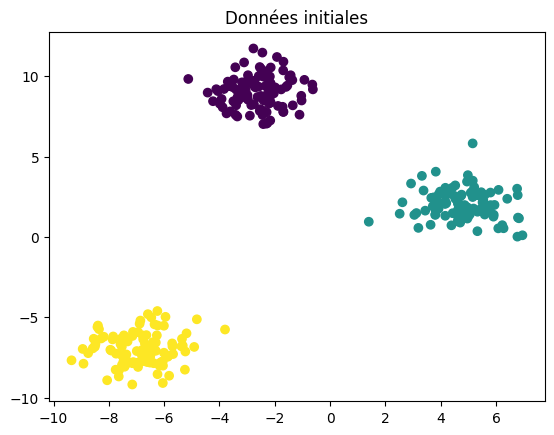

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, y = make_blobs(n_samples=300, centers=3, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Données initiales")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
mask = (y_train == 0) | (y_train == 1)

X_train_bin = X_train[mask]
y_train_bin = y_train[mask]

In [ ]:
w = np.zeros(2)
b = 0
lr = 0.1
epochs = 50

In [ ]:
def activation(z):
    return 1 if z >= 0 else 0

In [ ]:
for _ in range(epochs):
    for i in range(len(X_train_bin)):

        x = X_train_bin[i]
        y_true = y_train_bin[i]

        z = np.dot(x, w) + b
        y_pred = activation(z)

        error = y_true - y_pred

        w = w + lr * error * x
        b = b + lr * error

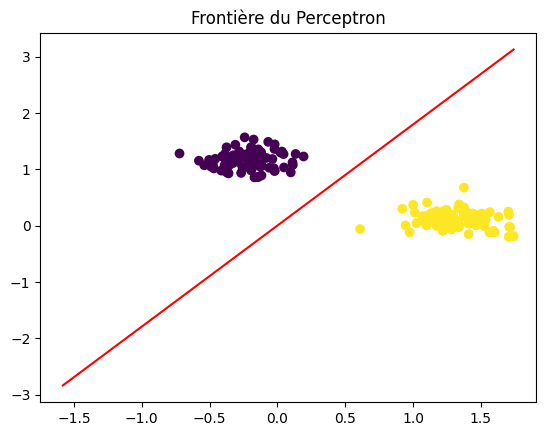

In [ ]:
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
y_vals = -(w[0]*x_vals + b) / w[1]

plt.scatter(X_train_bin[:,0], X_train_bin[:,1], c=y_train_bin)
plt.plot(x_vals, y_vals, color='red')
plt.title("Frontière du Perceptron")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

labels = kmeans.labels_

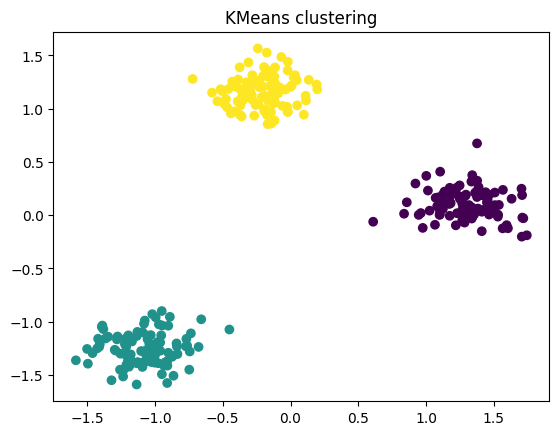

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("KMeans clustering")
plt.show()